# Analyzing the models learned in `surf_agent_unsupervised_10distinctobj_noise`

In this unsupervised continual-learning benchmark, Monty sees 10 distinct YCB objects
(mug, bowl, potted_meat_can, spoon, strawberry, mustard_bottle, dice, golf_ball,
c_lego_duplo, banana), one per episode, for 10 epochs (100 episodes total). Each episode
the object is shown in a new random rotation, and sensor noise is added to the raw
observations. Monty receives **no labels**: if it recognizes the object as one it has a
graph for, it updates that graph; if it detects `no_match`, it creates a brand-new graph
(`new_object0`, `new_object1`, ...).

Because recognition can fail in two directions, the learned graphs don't map 1:1 onto the
ground-truth objects:

- **`mean_graphs_per_object` > 1** — a ground-truth object was *split*: Monty failed to
  recognize an object it already had a model of (`no_match` on a known object), so it
  created a duplicate graph. The benchmark value for this run is **1.44**.
- **`mean_objects_per_graph` > 1** — ground-truth objects were *merged*: Monty `confused`
  one object for another and folded its observations into the wrong graph.

This notebook examines the models saved after every epoch to show what was learned, how
each model evolved, and how the learned graphs break down against the ground-truth
objects that were presented.

### Prerequisites

Run the experiment first (about 40 minutes; checkpoints are written after every epoch):

```bash
python run.py experiment=surf_agent_unsupervised_10distinctobj_noise
```

Results land in `~/tbp/results/monty/projects/monty_runs/surf_agent_unsupervised_10distinctobj_noise/`:

- `train_stats.csv` — one row per episode (BasicCSVStatsHandler).
- `{epoch}/model.pt` — full Monty state saved at the *end* of each epoch, including every
  learned graph plus the graph ↔ ground-truth bookkeeping dictionaries
  (`graph_id_to_target`, `target_to_graph_id`). Monty itself never uses these mappings —
  they exist purely for analysis like this.

Use the `tbp.monty` conda environment as the Jupyter kernel (it needs `torch`,
`torch_geometric`, `pandas`, and `matplotlib`).

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Patch

EXP_DIR = Path(
    "~/tbp/results/monty/projects/monty_runs/surf_agent_unsupervised_10distinctobj_noise"
).expanduser()

# One numbered directory per completed epoch, each containing a model.pt checkpoint.
EPOCHS = sorted(int(p.name) for p in EXP_DIR.iterdir() if p.name.isdigit())
print(f"Experiment dir: {EXP_DIR}")
print(f"Checkpoints found for epochs: {EPOCHS}")


def graph_number(graph_id: str) -> int:
    """'new_object12' -> 12, used for natural sorting of graph ids."""
    match = re.search(r"\d+", str(graph_id))
    return int(match.group()) if match else -1

/Users/nleadholm/miniconda3/envs/tbp.monty/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiment dir: /Users/nleadholm/tbp/results/monty/projects/monty_runs/surf_agent_unsupervised_10distinctobj_noise
Checkpoints found for epochs: [0, 1, 2, 3, 4, 5, 6, 7]


## 1. Episode-level results

`train_stats.csv` has one row per episode. The columns we care about:

- **`primary_target_object`** — the ground-truth object presented (Monty never sees this).
- **`primary_performance`** — `no_match` (new graph created), `correct` (matched a graph
  built from this object), `confused` (matched a graph built from a *different* object),
  or a timeout variant.
- **`result`** — the graph ID that was matched and subsequently updated with this
  episode's observations (or the newly created graph ID on `no_match`).
- **`mean_objects_per_graph` / `mean_graphs_per_object`** — running values of the two
  metrics. Note these are logged *before* the row's own episode updates the mapping, so
  the last row lags the final model state by one episode (we recompute the final values
  from the checkpoint in section 4).

In [2]:
stats = pd.read_csv(EXP_DIR / "train_stats.csv")

# Objects are presented in a fixed order within each epoch, so ground-truth epoch and
# episode indices can be derived from the row order.
objects = list(stats["primary_target_object"].drop_duplicates())
n_objects = len(objects)
stats["episode"] = np.arange(len(stats))
stats["epoch"] = stats["episode"] // n_objects

print(f"{len(stats)} episodes, {n_objects} objects, {stats['epoch'].nunique()} epochs")
print("\nPerformance counts over the whole run:")
print(stats["primary_performance"].value_counts().to_string())

key_columns = [
    "epoch",
    "episode",
    "primary_target_object",
    "primary_performance",
    "result",
    "possible_match_sources",
    "mean_objects_per_graph",
    "mean_graphs_per_object",
]
stats[key_columns].head(2 * n_objects)

84 episodes, 10 objects, 9 epochs

Performance counts over the whole run:
primary_performance
correct_mlh     31
correct         26
no_match        14
confused_mlh    12
confused         1


,epoch,episode,primary_target_object,primary_performance,result,possible_match_sources,mean_objects_per_graph,mean_graphs_per_object
0,0,0,mug,no_match,new_object0,NaN,NaN,NaN
1,0,1,bowl,no_match,new_object1,NaN,1.000000,1.000000
2,0,2,potted_meat_can,no_match,new_object2,NaN,1.000000,1.000000
3,0,3,spoon,no_match,new_object3,NaN,1.000000,1.000000
4,0,4,strawberry,no_match,new_object4,NaN,1.000000,1.000000
5,0,5,mustard_bottle,no_match,new_object5,NaN,1.000000,1.000000
6,0,6,dice,confused_mlh,['new_object3'],spoon,1.000000,1.000000
7,0,7,golf_ball,confused,new_object4,strawberry,1.000000,1.000000
8,0,8,c_lego_duplo,no_match,new_object6,NaN,1.166667,1.000000
9,0,9,banana,no_match,new_object7,NaN,1.142857,1.000000


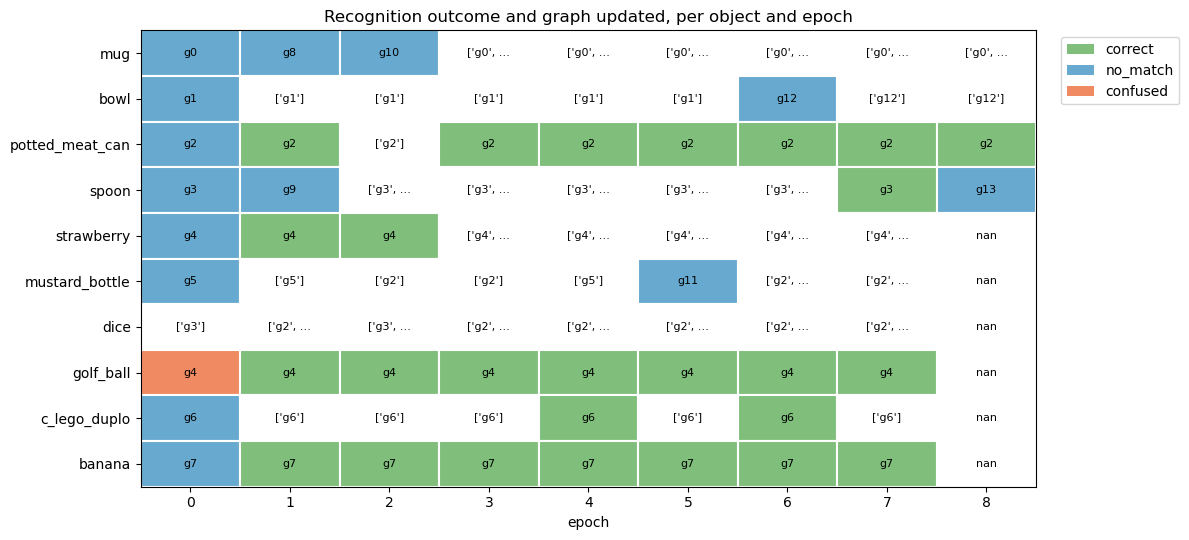

In [3]:
# Overview matrix: rows = ground-truth objects, columns = epochs.
# Cell color = recognition outcome; cell text = which graph was created/updated ("g3"
# is short for "new_object3"). Reading along a row shows every graph a ground-truth
# object contributed to; duplicate graph ids appearing in the same row after a blue
# (no_match) cell are the "splits" that push mean_graphs_per_object above 1.

performance_colors = {
    "correct": "#7fbf7b",
    "no_match": "#67a9cf",
    "confused": "#ef8a62",
    "pose_time_out": "#fee090",
    "time_out": "#fdcc8a",
    "patch_off_object": "#cccccc",
}

perf = stats.pivot(index="primary_target_object", columns="epoch",
                   values="primary_performance").reindex(objects)
result = stats.pivot(index="primary_target_object", columns="epoch",
                     values="result").reindex(objects)

fig, ax = plt.subplots(figsize=(12, 5.5))
n_epochs = perf.shape[1]
for row, obj in enumerate(perf.index):
    for col in range(n_epochs):
        outcome = perf.iloc[row, col]
        color = performance_colors.get(outcome, "white")
        ax.add_patch(plt.Rectangle((col, row), 1, 1, facecolor=color,
                                   edgecolor="white", lw=1.5))
        label = str(result.iloc[row, col])
        label = re.sub("new_object", "g", label)
        if len(label) > 8:  # e.g. a list of matches on time_out
            label = label[:7] + "…"
        ax.text(col + 0.5, row + 0.5, label, ha="center", va="center", fontsize=8)

ax.set_xlim(0, n_epochs)
ax.set_ylim(len(objects), 0)
ax.set_xticks(np.arange(n_epochs) + 0.5, labels=range(n_epochs))
ax.set_yticks(np.arange(len(objects)) + 0.5, labels=objects)
ax.set_xlabel("epoch")
ax.set_title("Recognition outcome and graph updated, per object and epoch")
legend_handles = [Patch(facecolor=c, label=l) for l, c in performance_colors.items()
                  if (perf.values == l).any()]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

How to read the matrix above:

- **Epoch 0 should be all blue (`no_match`)** — nothing is in memory yet, so each object
  gets a fresh graph (`g0`–`g9` for `new_object0`–`new_object9`).
- **A blue cell after epoch 0** is a recognition *miss* on a known object: Monty creates a
  duplicate graph for it. Every such cell adds a graph to that object's row and drives
  `mean_graphs_per_object` up.
- **An orange/red cell (`confused`)** means the episode's observations were merged into a
  graph originally built from a *different* object. That graph now contains data from two
  ground-truth objects, driving `mean_objects_per_graph` up.
- Once a duplicate graph exists, later `correct` episodes may update either copy — the row
  tells you which graph absorbed each epoch's observations.

## 2. Metric trajectories over the run

Both metrics start at 1.0 (10 objects → 10 graphs after epoch 0) and drift as splits and
merges accumulate.

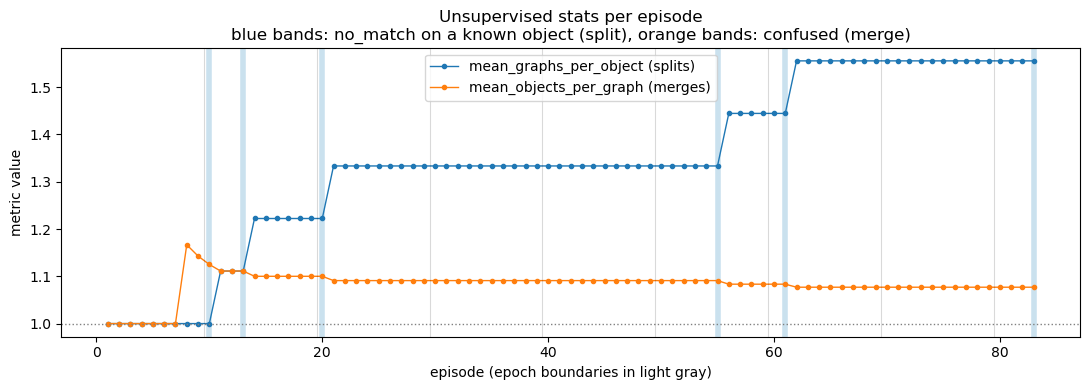

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(stats["episode"], stats["mean_graphs_per_object"], marker=".", lw=1,
        label="mean_graphs_per_object (splits)")
ax.plot(stats["episode"], stats["mean_objects_per_graph"], marker=".", lw=1,
        label="mean_objects_per_graph (merges)")
ax.axhline(1.0, color="gray", ls=":", lw=1)

# Mark the episodes that change the metrics.
for outcome, color in [("no_match", "#67a9cf"), ("confused", "#ef8a62")]:
    episodes = stats.loc[
        (stats["primary_performance"] == outcome) & (stats["epoch"] > 0), "episode"
    ]
    for episode in episodes:
        ax.axvline(episode, color=color, alpha=0.35, lw=4, zorder=0)

for boundary in range(n_objects, len(stats), n_objects):
    ax.axvline(boundary - 0.5, color="k", alpha=0.15, lw=0.8)

ax.set_xlabel("episode (epoch boundaries in light gray)")
ax.set_ylabel("metric value")
ax.set_title("Unsupervised stats per episode\n"
             "blue bands: no_match on a known object (split), "
             "orange bands: confused (merge)")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Loading the per-epoch model checkpoints

Each `{epoch}/model.pt` contains the learning module's full state at the end of that
epoch. We pull out three things:

- `graph_memory` — dict of `graph_id -> {input_channel -> GraphObjectModel}`. The graph's
  nodes (`model.pos`) are 3D points in the object's reference frame; `model.x` holds the
  features stored at each node (surface normals, curvature, HSV color, ...).
- `graph_id_to_target` — for each graph, the set of ground-truth objects whose episodes
  were used to build/extend it.
- `target_to_graph_id` — for each ground-truth object, the set of graphs it contributed to.

An important detail for the visualizations later: when a graph is extended, the existing
nodes are kept unchanged at the *front* of the node array and new points are appended.
So by comparing node counts across epochs we can tell in which epoch each node was added.

In [5]:
def load_lm_state(epoch: int) -> dict:
    """LM state (graph memory + graph<->target mappings) saved at the end of `epoch`."""
    state_dict = torch.load(EXP_DIR / str(epoch) / "model.pt", weights_only=False)
    return state_dict["lm_dict"][0]


def get_models(lm_state: dict) -> dict:
    """graph_id -> GraphObjectModel (single input channel, 'patch')."""
    return {
        graph_id: channels["patch"]
        for graph_id, channels in lm_state["graph_memory"].items()
    }


lm_states = {epoch: load_lm_state(epoch) for epoch in EPOCHS}

all_graph_ids = sorted(get_models(lm_states[EPOCHS[-1]]).keys(), key=graph_number)

node_counts = pd.DataFrame(index=all_graph_ids, columns=EPOCHS, dtype="Int64")
for epoch in EPOCHS:
    for graph_id, model in get_models(lm_states[epoch]).items():
        node_counts.loc[graph_id, epoch] = model.num_nodes

print(f"{len(all_graph_ids)} graphs in memory after the final epoch\n")
print("Number of nodes in each graph at the end of each epoch")
print("(blank = graph does not exist yet):")
node_counts

13 graphs in memory after the final epoch

Number of nodes in each graph at the end of each epoch
(blank = graph does not exist yet):


,0,1,2,3,4,5,6,7
new_object0,295,295,295,295,295,295,295,295
new_object1,299,299,299,299,299,299,299,299
new_object2,273,502,502,694,854,992,1108,1256
new_object3,186,186,186,186,186,186,186,303
new_object4,303,391,449,469,485,531,574,606
new_object5,320,320,320,320,320,320,320,320
new_object6,186,186,186,186,304,304,373,373
new_object7,295,527,717,874,996,1089,1172,1260
new_object8,<NA>,263,263,263,263,263,263,263
new_object9,<NA>,160,160,160,160,160,160,160


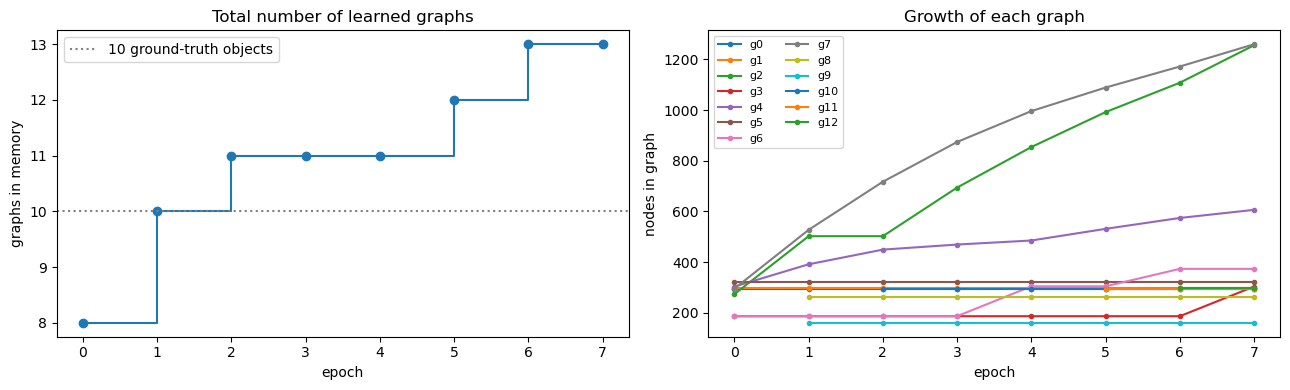

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].step(EPOCHS, [node_counts[e].notna().sum() for e in EPOCHS], where="post",
             marker="o")
axes[0].axhline(n_objects, color="gray", ls=":", label=f"{n_objects} ground-truth objects")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("graphs in memory")
axes[0].set_title("Total number of learned graphs")
axes[0].legend()

for graph_id in all_graph_ids:
    counts = node_counts.loc[graph_id].astype("float")
    axes[1].plot(EPOCHS, counts, marker=".", label=re.sub("new_object", "g", graph_id))
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("nodes in graph")
axes[1].set_title("Growth of each graph")
axes[1].legend(ncols=2, fontsize=8)

fig.tight_layout()
plt.show()

## 4. How the learned graphs break down vs. the ground-truth objects

Two complementary views:

1. The bookkeeping dictionaries from the final checkpoint tell us *which* ground-truth
   objects each graph was built from (and vice versa) — this is exactly what
   `mean_objects_per_graph` and `mean_graphs_per_object` are computed from.
2. A confusion matrix of episode counts (ground-truth object presented × graph updated)
   shows *how much* each object contributed to each graph.

In [7]:
final_state = lm_states[EPOCHS[-1]]
graph_to_target = final_state["graph_id_to_target"]  # graph -> set of true objects
target_to_graph = final_state["target_to_graph_id"]  # true object -> set of graphs

mean_objects_per_graph = np.mean([len(t) for t in graph_to_target.values()])
mean_graphs_per_object = np.mean([len(g) for g in target_to_graph.values()])
print(f"Final mean_objects_per_graph: {mean_objects_per_graph:.2f}")
print(f"Final mean_graphs_per_object: {mean_graphs_per_object:.2f}\n")

print("=== Graphs built from MULTIPLE objects (merges -> objects_per_graph > 1) ===")
for graph_id in sorted(graph_to_target, key=graph_number):
    targets = graph_to_target[graph_id]
    if len(targets) > 1:
        print(f"  {graph_id}: {sorted(targets)}")

print("\n=== Objects split across MULTIPLE graphs (splits -> graphs_per_object > 1) ===")
for target in objects:
    graphs = target_to_graph.get(target, set())
    if len(graphs) > 1:
        print(f"  {target}: {sorted(graphs, key=graph_number)}")

print("\n=== Full mapping: ground-truth object -> graphs ===")
for target in objects:
    graphs = sorted(target_to_graph.get(target, set()), key=graph_number)
    print(f"  {target:>18}: {graphs}")

Final mean_objects_per_graph: 1.08
Final mean_graphs_per_object: 1.56

=== Graphs built from MULTIPLE objects (merges -> objects_per_graph > 1) ===
  new_object4: ['golf_ball', 'strawberry']

=== Objects split across MULTIPLE graphs (splits -> graphs_per_object > 1) ===
  mug: ['new_object0', 'new_object8', 'new_object10']
  bowl: ['new_object1', 'new_object12']
  spoon: ['new_object3', 'new_object9']
  mustard_bottle: ['new_object5', 'new_object11']

=== Full mapping: ground-truth object -> graphs ===
                 mug: ['new_object0', 'new_object8', 'new_object10']
                bowl: ['new_object1', 'new_object12']
     potted_meat_can: ['new_object2']
               spoon: ['new_object3', 'new_object9']
          strawberry: ['new_object4']
      mustard_bottle: ['new_object5', 'new_object11']
                dice: []
           golf_ball: ['new_object4']
        c_lego_duplo: ['new_object6']
              banana: ['new_object7']


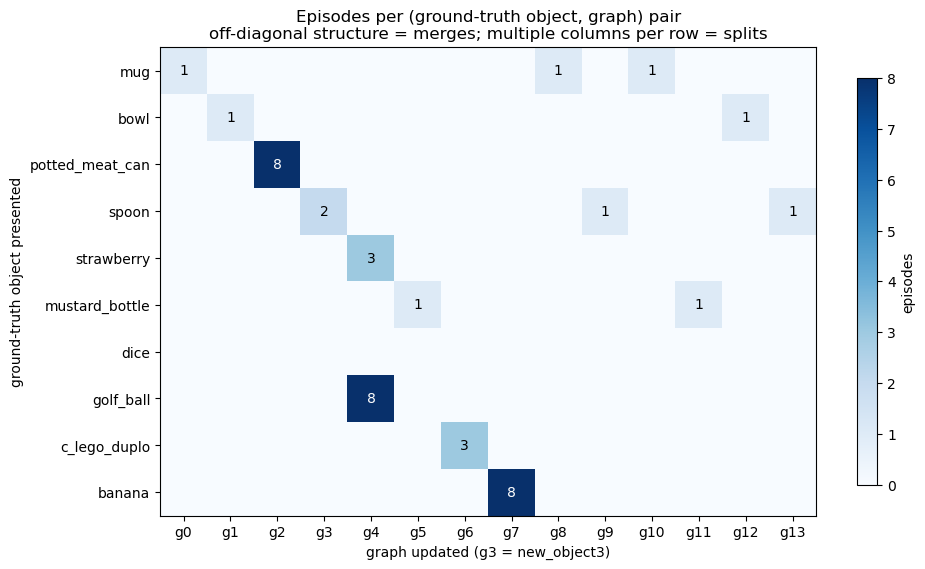

In [8]:
# Confusion matrix: how many episodes of each ground-truth object went into each graph.
# (Episodes that timed out without a single match are excluded; `result` is then a list
# of candidates rather than one graph.)
matched = stats[stats["result"].astype(str).str.fullmatch(r"new_object\d+")]
confusion = pd.crosstab(matched["primary_target_object"], matched["result"])
confusion = confusion.reindex(index=objects,
                              columns=sorted(confusion.columns, key=graph_number),
                              fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(confusion.values, cmap="Blues", vmin=0)
ax.set_xticks(range(confusion.shape[1]),
              labels=[re.sub("new_object", "g", c) for c in confusion.columns])
ax.set_yticks(range(confusion.shape[0]), labels=confusion.index)
for row in range(confusion.shape[0]):
    for col in range(confusion.shape[1]):
        count = confusion.values[row, col]
        if count > 0:
            ax.text(col, row, count, ha="center", va="center",
                    color="white" if count > confusion.values.max() / 2 else "black")
ax.set_xlabel("graph updated (g3 = new_object3)")
ax.set_ylabel("ground-truth object presented")
ax.set_title("Episodes per (ground-truth object, graph) pair\n"
             "off-diagonal structure = merges; multiple columns per row = splits")
fig.colorbar(im, ax=ax, shrink=0.8, label="episodes")
fig.tight_layout()
plt.show()

## 5. Visualizing the learned object models

First a gallery of every graph in memory after the final epoch. Nodes are plotted at
their stored 3D locations and colored with the HSV color stored at each node (clipped to
valid range, since this run adds sensor noise), so models should be recognizable — e.g.
the banana model should be yellow and banana-shaped.

Each title lists the ground-truth objects that contributed to the graph. Graphs built
from more than one object are flagged with `MERGED`.

Note that each graph lives in its own reference frame, anchored to the object pose in the
episode that created it. Duplicate graphs of the same object therefore usually appear in
different orientations.

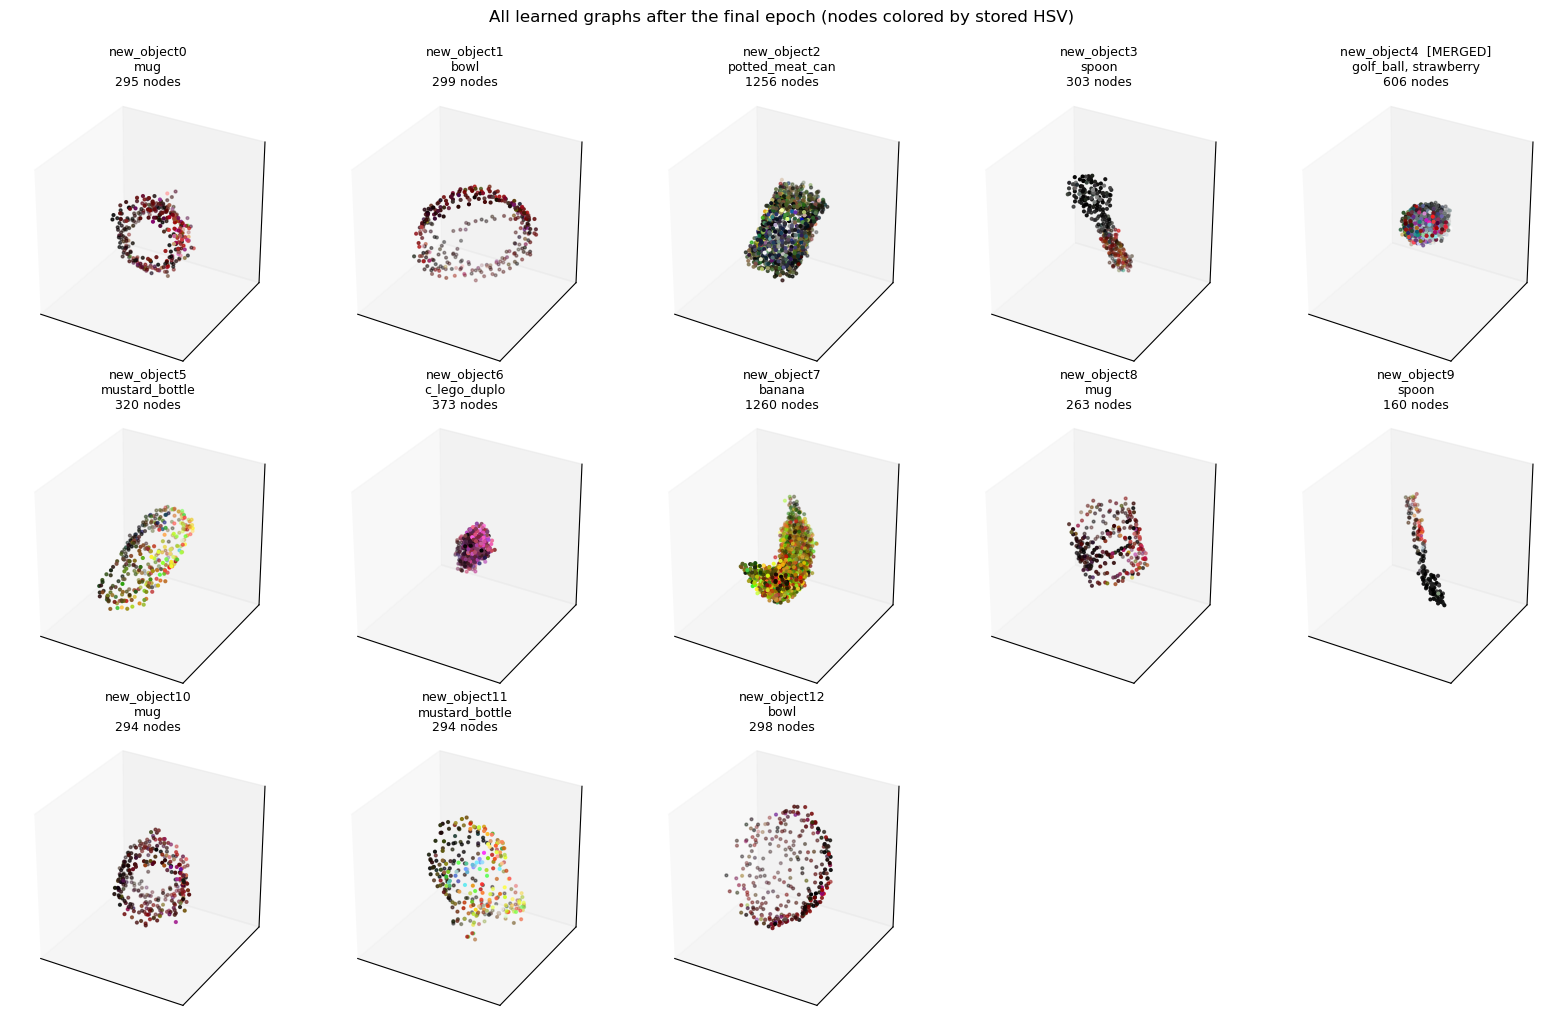

In [17]:
def node_rgb_colors(model) -> np.ndarray:
    """RGB color per node from the HSV feature stored in the graph."""
    hsv = np.asarray(model.get_values_for_feature("hsv"))
    return hsv_to_rgb(np.clip(hsv, 0.0, 1.0))


def compute_global_extent(models):
    """Compute the global min/max extents across all models to set same bounds for all axes."""
    all_pos = np.concatenate([np.asarray(m.pos) for m in models.values()])
    mins = all_pos.min(axis=0)
    maxs = all_pos.max(axis=0)
    centers = (mins + maxs) / 2
    max_range = (maxs - mins).max() / 2
    return centers, max_range

def scatter_model(ax, model, colors=None, point_size=4, global_centers=None, global_max_range=None):
    """3D scatter of a graph's nodes, with common axis extents so objects aren't distorted."""
    pos = np.asarray(model.pos)
    if colors is None:
        colors = pos[:, 2]
    scatter = ax.scatter(pos[:, 1], pos[:, 0], pos[:, 2], c=colors, s=point_size)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    # Fall back to this model's own extents if no global ones are provided.
    if global_centers is None or global_max_range is None:
        mins, maxs = pos.min(axis=0), pos.max(axis=0)
        global_centers = (mins + maxs) / 2
        global_max_range = (maxs - mins).max() / 2
    # Identical limits for each axis, so one unit is the same length in x, y, and z.
    ax.set_xlim(global_centers[1] - global_max_range, global_centers[1] + global_max_range)
    ax.set_ylim(global_centers[0] - global_max_range, global_centers[0] + global_max_range)
    ax.set_zlim(global_centers[2] - global_max_range, global_centers[2] + global_max_range)
    # Equal limits alone aren't enough: matplotlib draws the 3D box with a
    # non-cubic aspect by default, so force it to be a cube.
    ax.set_box_aspect((1, 1, 1))
    return scatter


def graph_title(graph_id: str, model) -> str:
    targets = sorted(graph_to_target.get(graph_id, set()))
    flag = "  [MERGED]" if len(targets) > 1 else ""
    return f"{graph_id}{flag}\n{', '.join(targets)}\n{model.num_nodes} nodes"


final_models = get_models(final_state)
n_graphs = len(all_graph_ids)
n_cols = 5
n_rows = int(np.ceil(n_graphs / n_cols))
# Compute shared centers and range for all graphs
global_centers, global_max_range = compute_global_extent(final_models)
fig = plt.figure(figsize=(3.2 * n_cols, 3.4 * n_rows))
for i, graph_id in enumerate(all_graph_ids):
    model = final_models[graph_id]
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection="3d")
    scatter_model(
        ax, model, colors=node_rgb_colors(model),
        global_centers=global_centers, global_max_range=global_max_range,
    )
    ax.set_title(graph_title(graph_id, model), fontsize=9)
fig.suptitle("All learned graphs after the final epoch (nodes colored by stored HSV)",
             y=1.0)
fig.tight_layout()
plt.show()

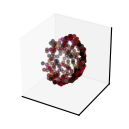

In [20]:
# Visualize just a single graph, interactively: drag to rotate, scroll to zoom,
# hover for node coordinates.
import plotly.graph_objects as go

final_models = get_models(final_state)
graph_id = "new_object0"
model = final_models[graph_id]

pos = np.asarray(model.pos)
rgb = (node_rgb_colors(model) * 255).astype(int)
point_colors = [f"rgb({r},{g},{b})" for r, g, b in rgb]

fig = go.Figure(
    go.Scatter3d(
        # Same axis mapping as scatter_model: (x, y, z) = pos[:, (1, 0, 2)].
        x=pos[:, 1], y=pos[:, 0], z=pos[:, 2],
        mode="markers",
        marker=dict(size=3, color=point_colors),
        hovertemplate="node %{pointNumber}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    )
)
fig.update_layout(
    title=f"{graph_id} — {model.num_nodes} nodes",
    width=700, height=700,
    margin=dict(l=0, r=0, t=40, b=0),
    # Cube aspect with the shared global extents, matching scatter_model.
    scene=dict(
        aspectmode="cube",
        xaxis=dict(range=[global_centers[1] - global_max_range,
                          global_centers[1] + global_max_range], visible=False),
        yaxis=dict(range=[global_centers[0] - global_max_range,
                          global_centers[0] + global_max_range], visible=False),
        zaxis=dict(range=[global_centers[2] - global_max_range,
                          global_centers[2] + global_max_range], visible=False),
    ),
)
fig.show()

### 5.1 How each model changed over epochs

For a given graph we plot its state at the end of every epoch it existed. Nodes are
colored by the epoch in which they were added (possible because updates only ever append
nodes). This shows both when a model grew and *where* on the object the new observations
landed. A graph that stops growing either stopped being matched (a duplicate took over)
or the object was already fully covered (new points fall within the
`graph_delta_thresholds` of existing nodes and are discarded).

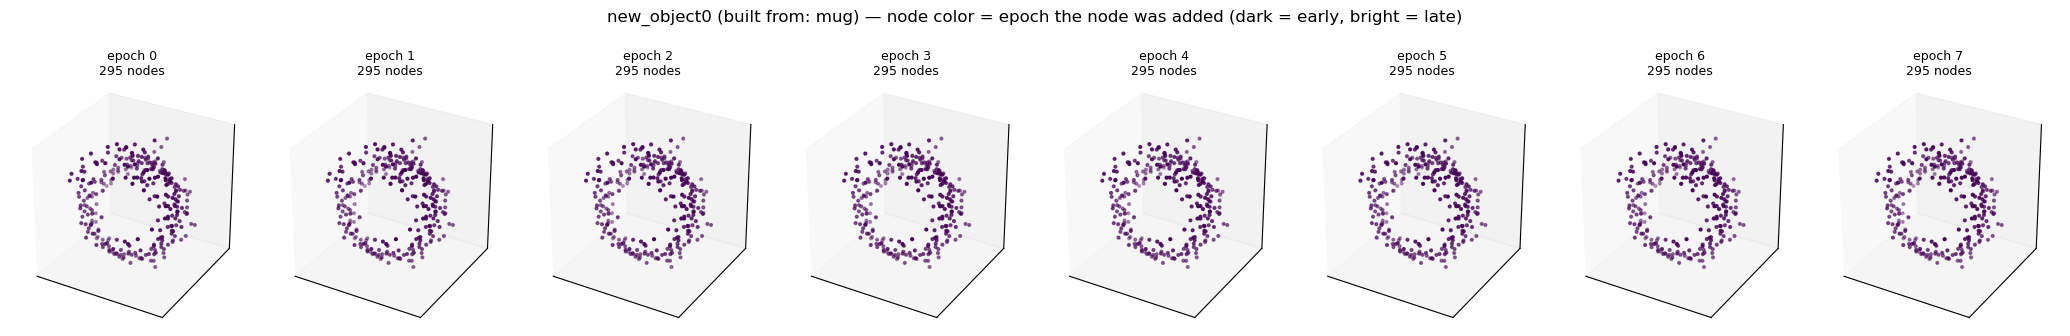

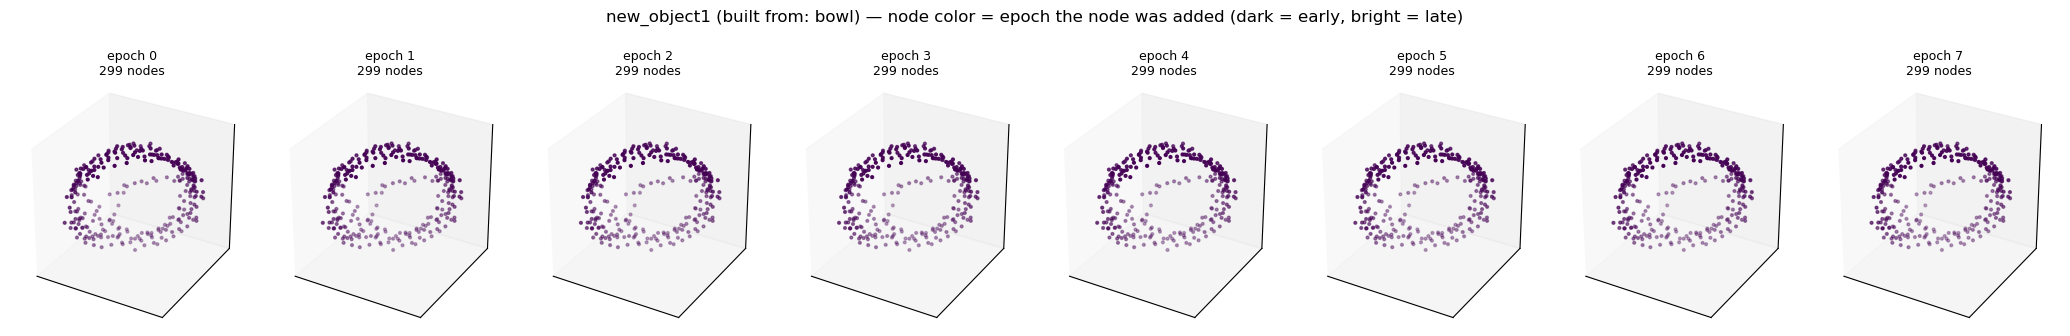

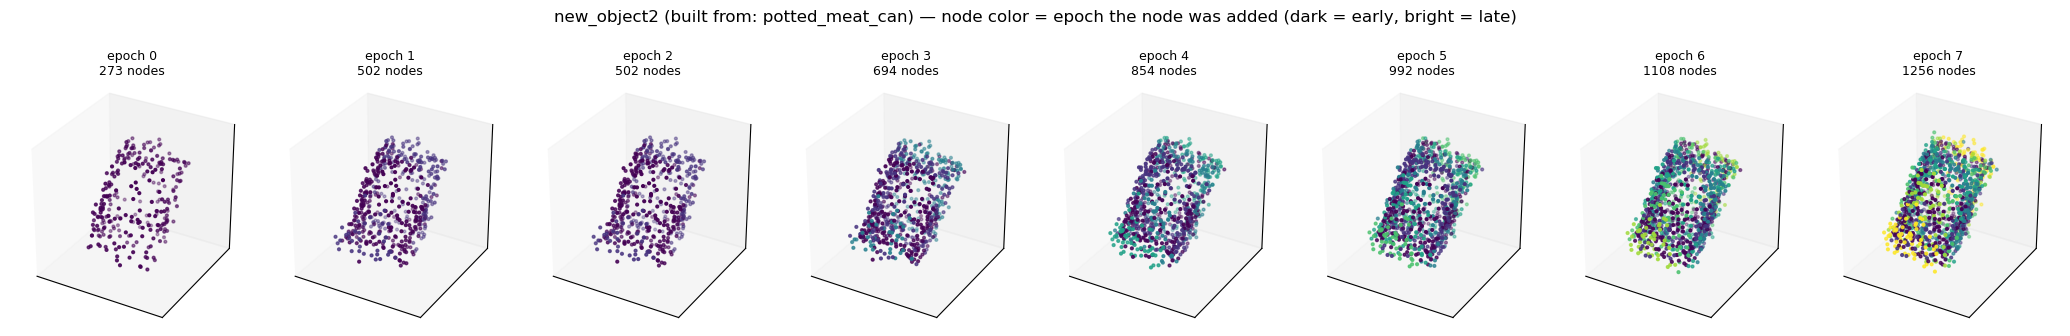

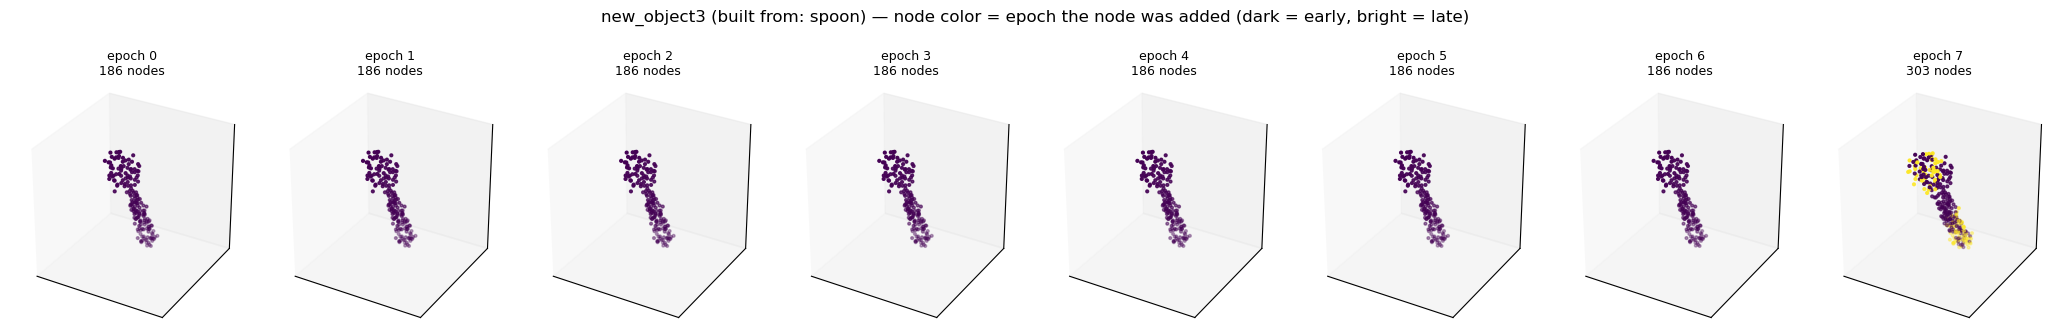

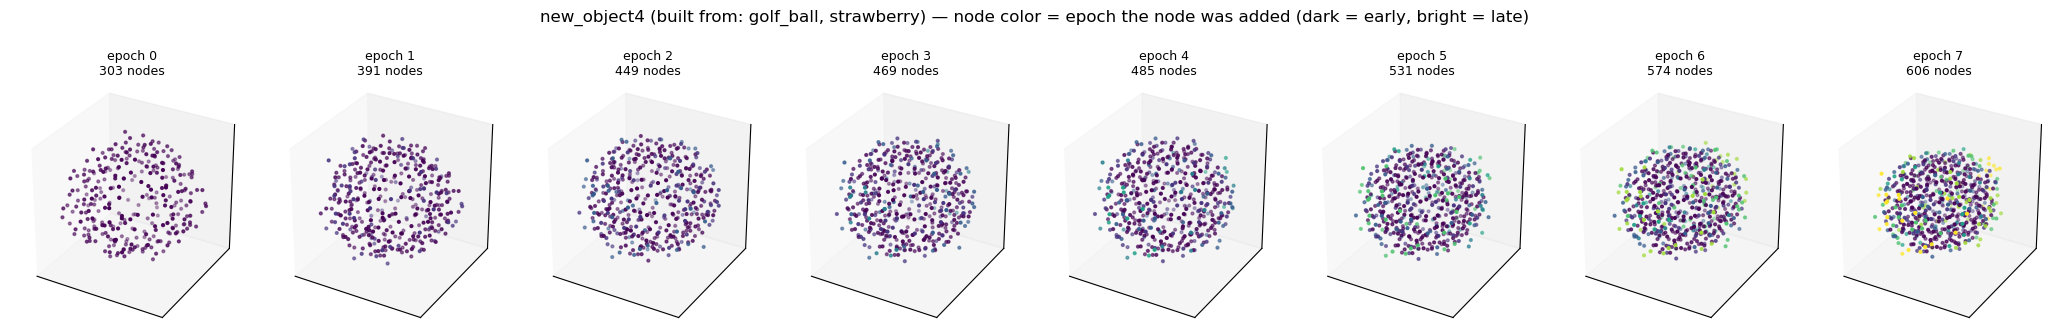

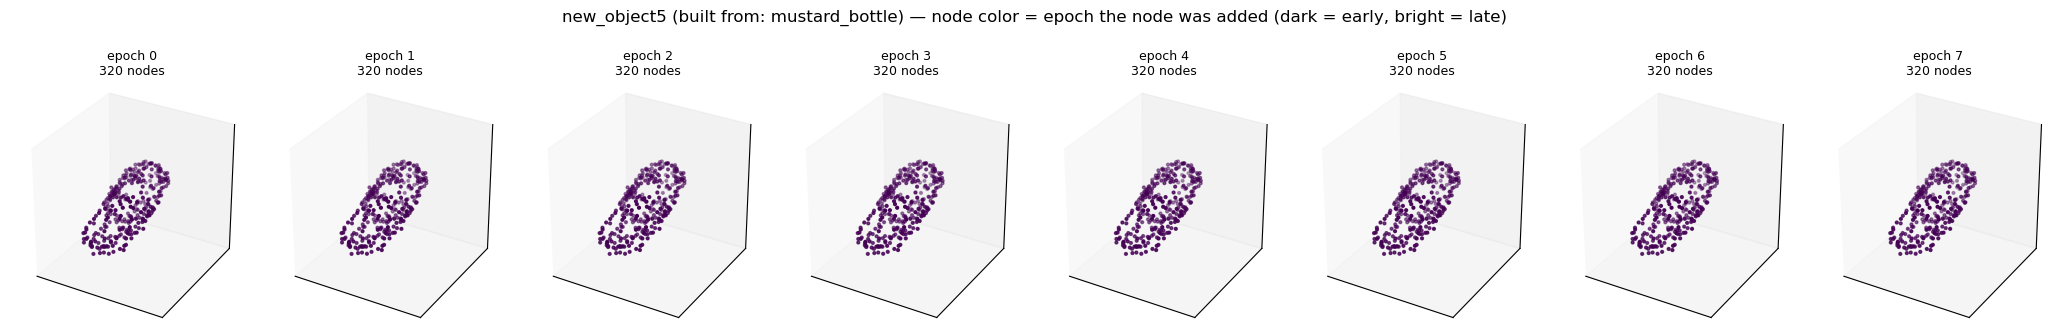

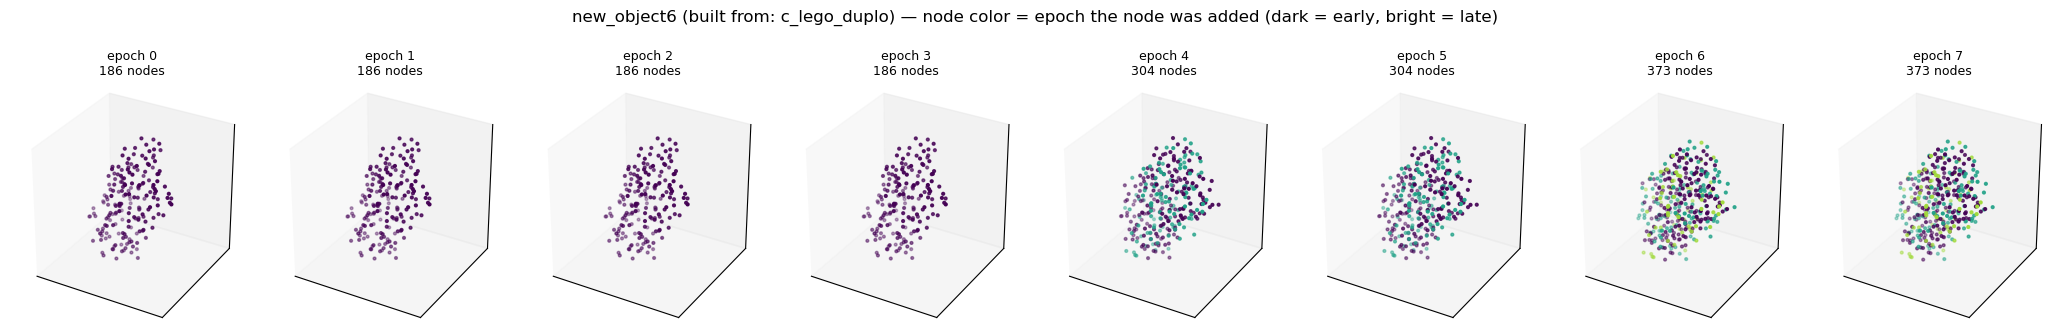

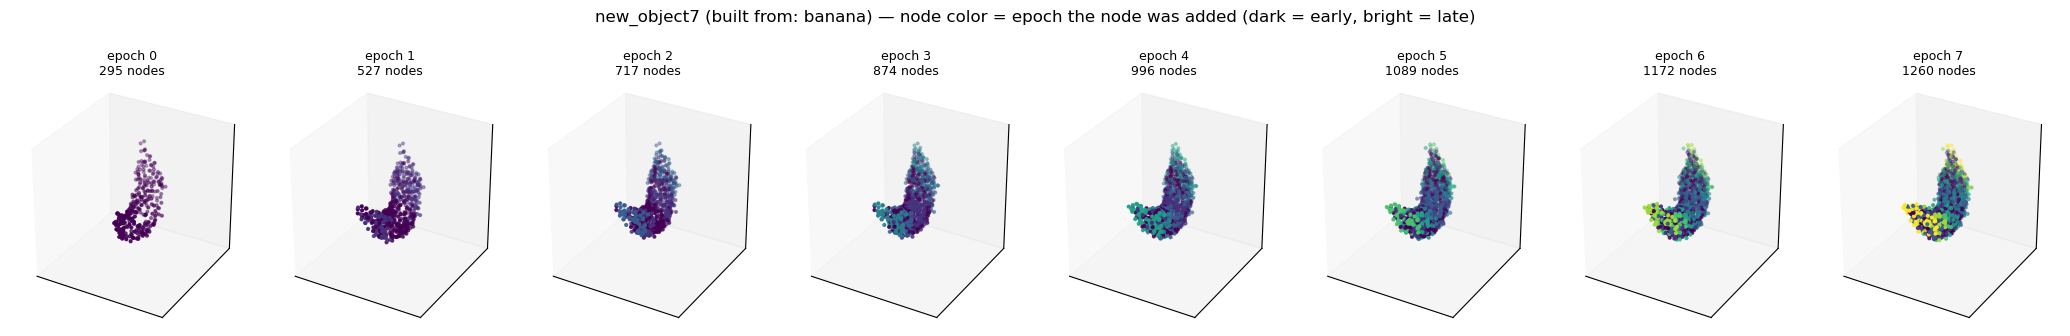

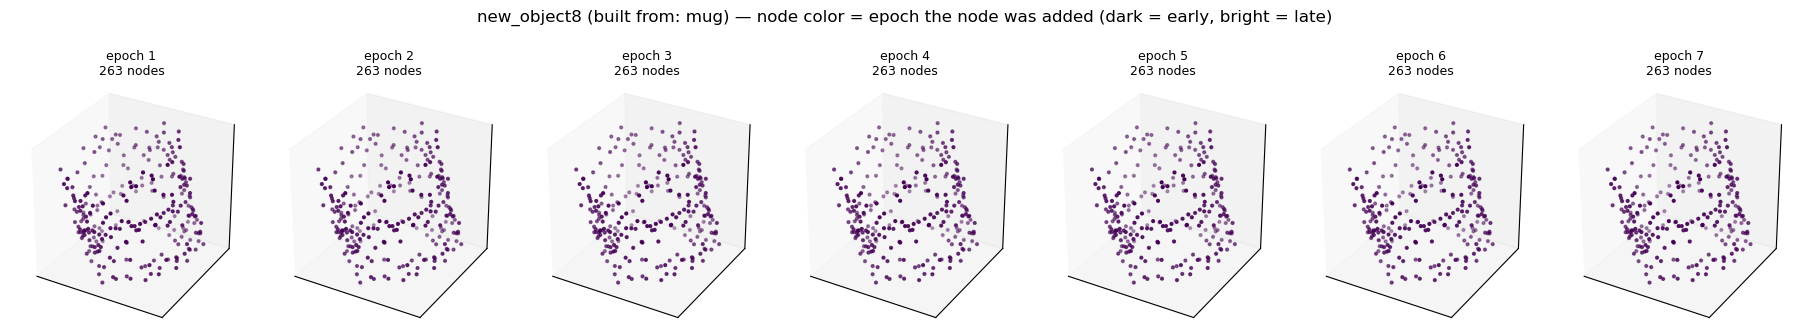

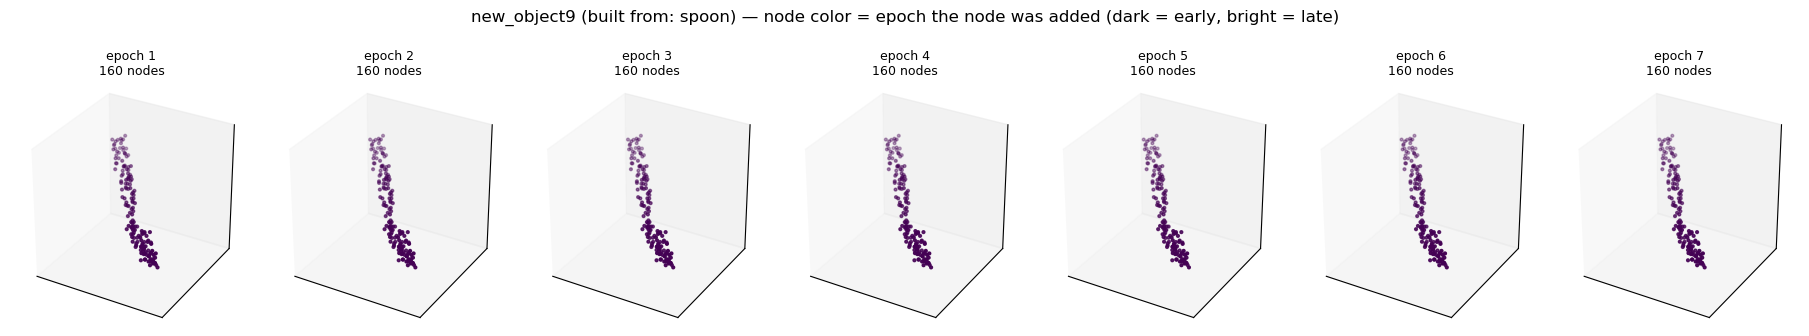

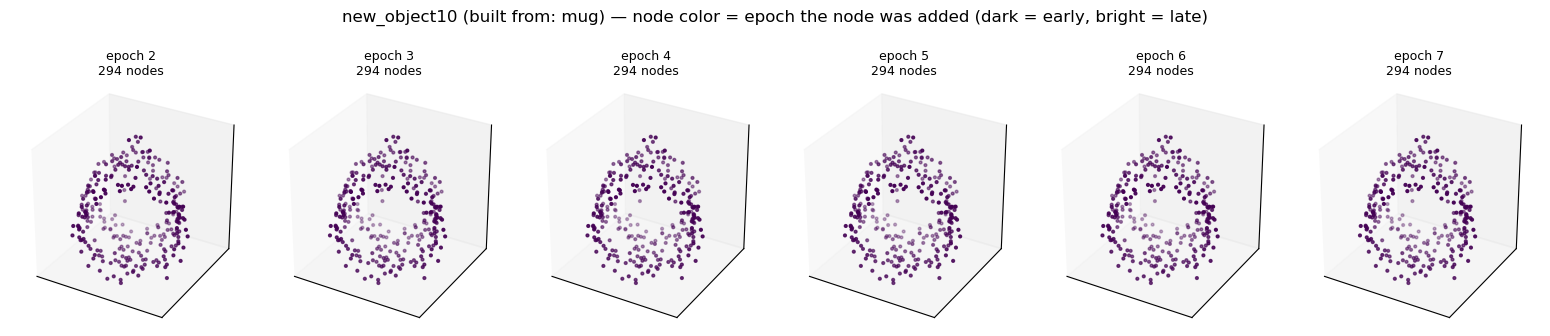

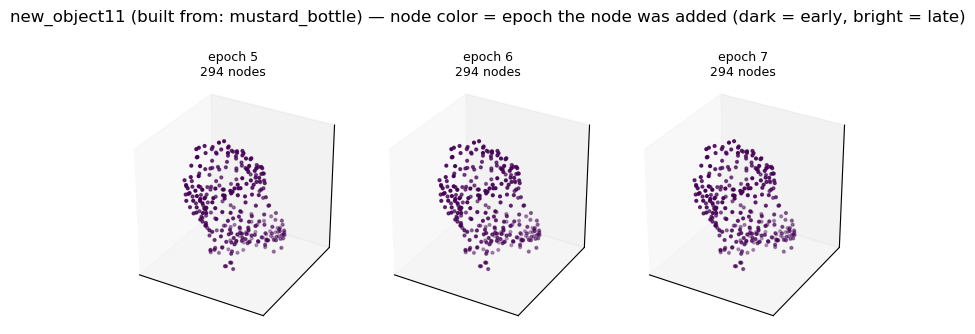

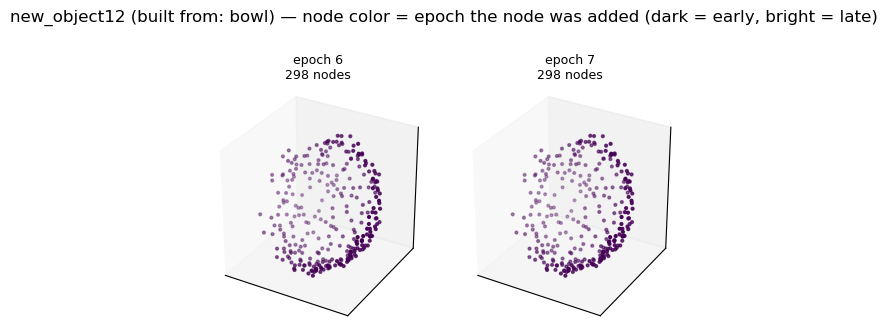

In [16]:
def plot_model_evolution(graph_id: str):
    """One row of 3D plots: the graph at the end of each epoch it exists in.

    Nodes are colored by the epoch in which they were first added to the graph.
    """
    epochs_present = [e for e in EPOCHS if not pd.isna(node_counts.loc[graph_id, e])]
    counts = [int(node_counts.loc[graph_id, e]) for e in epochs_present]
    cmap = plt.get_cmap("viridis", len(epochs_present))

    fig = plt.figure(figsize=(2.6 * len(epochs_present), 3.2))
    for i, epoch in enumerate(epochs_present):
        model = get_models(lm_states[epoch])[graph_id]
        # Node j was added in the first epoch whose cumulative count exceeds j.
        epoch_added = np.searchsorted(np.array(counts), np.arange(model.num_nodes),
                                      side="right")
        ax = fig.add_subplot(1, len(epochs_present), i + 1, projection="3d")
        scatter_model(ax, model, colors=cmap(epoch_added))
        ax.set_title(f"epoch {epoch}\n{model.num_nodes} nodes", fontsize=9)

    targets = sorted(graph_to_target.get(graph_id, set()))
    fig.suptitle(
        f"{graph_id} (built from: {', '.join(targets)}) — "
        "node color = epoch the node was added (dark = early, bright = late)",
        y=1.06,
    )
    fig.tight_layout()
    plt.show()


# Plot the evolution of every graph. To look at a single model, call e.g.
# plot_model_evolution("new_object0")
for graph_id in all_graph_ids:
    plot_model_evolution(graph_id)

### 5.2 Split objects: comparing the duplicate graphs side by side

For every ground-truth object that ended up with more than one graph (the source of
`mean_graphs_per_object` = 1.44), we plot all of its graphs next to each other. Things to
look for:

- The duplicates are typically partial models in *different orientations* (each graph's
  reference frame comes from the pose of the episode that created it). A common failure
  mode is that the first model only covered part of the object, and a later episode
  started on the unmodeled side under noise, yielding `no_match`.
- The episode-count annotation (from the confusion matrix) shows whether the duplicate
  "took over" matching in later epochs or remained a rarely-updated fragment.

In [ ]:
split_objects = {
    target: sorted(graphs, key=graph_number)
    for target, graphs in target_to_graph.items()
    if len(graphs) > 1
}

for target, graph_ids in split_objects.items():
    fig = plt.figure(figsize=(3.2 * len(graph_ids), 3.6))
    for i, graph_id in enumerate(graph_ids):
        model = final_models[graph_id]
        n_episodes = int(confusion.loc[target, graph_id]) \
            if graph_id in confusion.columns else 0
        ax = fig.add_subplot(1, len(graph_ids), i + 1, projection="3d")
        scatter_model(ax, model, colors=node_rgb_colors(model))
        also = sorted(graph_to_target.get(graph_id, set()) - {target})
        extra = f"\n(also contains: {', '.join(also)})" if also else ""
        ax.set_title(f"{graph_id}\n{model.num_nodes} nodes, "
                     f"{n_episodes} episodes of {target}{extra}", fontsize=9)
    fig.suptitle(f"'{target}' was split across {len(graph_ids)} graphs", y=1.04)
    fig.tight_layout()
    plt.show()

if not split_objects:
    print("No ground-truth object was split across multiple graphs in this run.")

### 5.3 Merged graphs: which objects got mixed into one model

For every graph built from more than one ground-truth object (the source of
`mean_objects_per_graph` > 1), we show the merged graph alongside a reference graph for
each of the other contributing objects. The merged graph may show one object's shape with
a patch of misplaced points from the confused episode, or two overlapping shapes.

In [ ]:
merged_graphs = {
    graph_id: sorted(targets)
    for graph_id, targets in graph_to_target.items()
    if len(targets) > 1
}

for graph_id, targets in merged_graphs.items():
    # For each contributing object, find its most-updated other graph as a reference.
    references = []
    for target in targets:
        candidates = [
            g for g in target_to_graph.get(target, set())
            if g != graph_id and g in confusion.columns
        ]
        if candidates:
            best = max(candidates, key=lambda g: confusion.loc[target, g])
            references.append((best, target))

    fig = plt.figure(figsize=(3.4 * (1 + len(references)), 3.8))
    ax = fig.add_subplot(1, 1 + len(references), 1, projection="3d")
    model = final_models[graph_id]
    scatter_model(ax, model, colors=node_rgb_colors(model))
    ax.set_title(f"MERGED: {graph_id}\nbuilt from {', '.join(targets)}\n"
                 f"{model.num_nodes} nodes", fontsize=9)
    for i, (ref_id, target) in enumerate(references):
        ax = fig.add_subplot(1, 1 + len(references), i + 2, projection="3d")
        ref_model = final_models[ref_id]
        scatter_model(ax, ref_model, colors=node_rgb_colors(ref_model))
        ax.set_title(f"reference for '{target}':\n{ref_id}, "
                     f"{ref_model.num_nodes} nodes", fontsize=9)
    fig.tight_layout()
    plt.show()

if not merged_graphs:
    print("No graph was built from multiple ground-truth objects in this run.")

## 6. Summary

The cell below prints a compact report of everything above: final metric values, which
episodes created duplicate graphs (splits), and which episodes merged objects into the
wrong graph.

In [ ]:
print(f"Objects presented:        {n_objects}")
print(f"Graphs in final memory:   {len(all_graph_ids)}")
print(f"mean_graphs_per_object:   {mean_graphs_per_object:.2f}  "
      "(>1 -> objects were split into duplicate graphs)")
print(f"mean_objects_per_graph:   {mean_objects_per_graph:.2f}  "
      "(>1 -> objects were merged into shared graphs)")

splits = stats[(stats["primary_performance"] == "no_match") & (stats["epoch"] > 0)]
print(f"\nSplit events (no_match on a known object): {len(splits)}")
for _, row in splits.iterrows():
    print(f"  epoch {row['epoch']}, episode {row['episode']}: "
          f"{row['primary_target_object']} not recognized -> created {row['result']}")

merges = stats[stats["primary_performance"] == "confused"]
print(f"\nMerge events (confused): {len(merges)}")
for _, row in merges.iterrows():
    contents = sorted(graph_to_target.get(row["result"], set()))
    print(f"  epoch {row['epoch']}, episode {row['episode']}: "
          f"{row['primary_target_object']} matched to {row['result']} "
          f"(that graph now contains: {contents})")

timeouts = stats[stats["primary_performance"].isin(["time_out", "pose_time_out"])]
print(f"\nTime-out episodes (no graph update attributed): {len(timeouts)}")
for _, row in timeouts.iterrows():
    print(f"  epoch {row['epoch']}, episode {row['episode']}: "
          f"{row['primary_target_object']} -> {row['primary_performance']}")